# **Linear Regression**

## **Checking Assumptions**

Always verify assumptions before trusting a linear regression model.
1. Linearity
2. Low multicollinearity
3. Residual normality
4. Independent errors
5. Constant variance



In [1]:
# pip install scikit-learn seaborn statsmodels

## **1. Nonlinear Relationships**

Linear regression assumes a linear relationship between inputs and target.

- **Problem:** A curved relationship is fit with a straight line.
- **Solution:** Add polynomial features or use another nonlinear model.


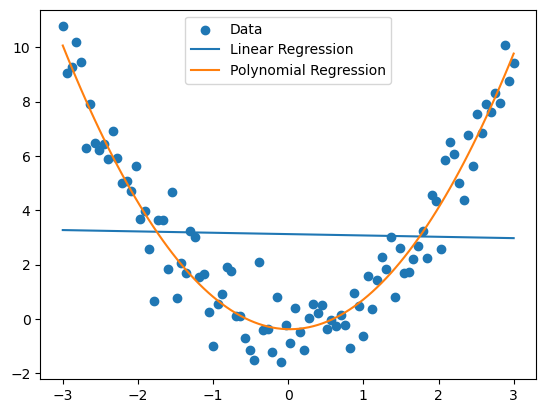

In [2]:
# Example

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

np.random.seed(0)
X = np.linspace(-3, 3, 100).reshape(-1, 1)
y = X[:,0]**2 + np.random.normal(0, 1, 100)

lin = LinearRegression().fit(X, y)
poly = make_pipeline(PolynomialFeatures(2), LinearRegression())
poly.fit(X, y)

plt.scatter(X, y, label="Data")
plt.plot(X, lin.predict(X), label="Linear Regression")
plt.plot(X, poly.predict(X), label="Polynomial Regression")
plt.legend()
plt.show()


#### **Detection**
To verify linearity, the most important idea is:

- The relationship between each feature and the target should look approximately like a straight line.
- The residuals should not show a systematic pattern (Residuals are:$e_i = y_i - \hat{y}_i$ )
    - Random cloud around zero → linearity is probably okay
    - Curved pattern → nonlinearity
    - Funnel shape → heteroscedasticity, not linearity

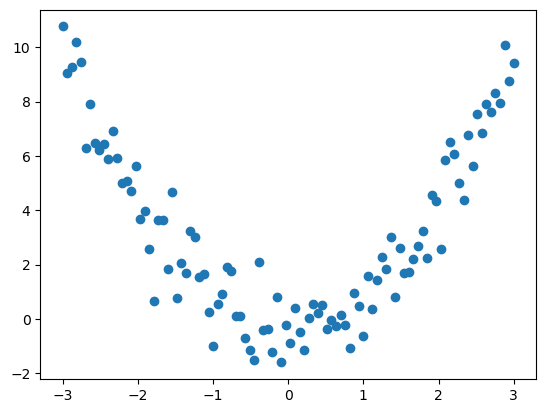

In [3]:
# The relationship between each feature and the target should look approximately like a straight line.
plt.scatter(X, y)

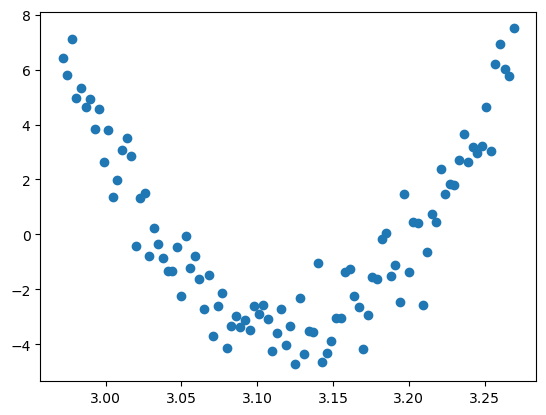

In [4]:
# The residuals should not show a systematic pattern.
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)
residuals = y - y_pred

plt.scatter(y_pred, residuals);

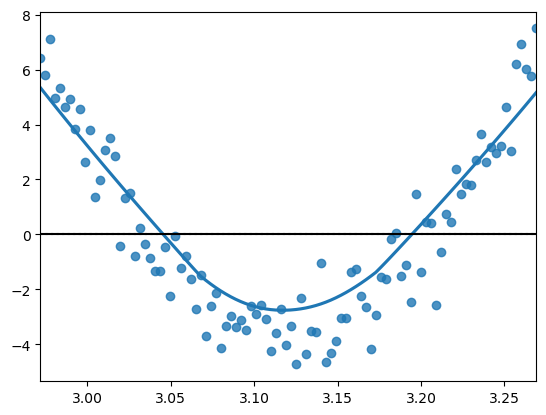

In [5]:
# the LOWESS should show smoothing line
# Flat LOWESS line near zero → linearity holds
# Curved LOWESS line → likely nonlinear

import seaborn as sns

sns.residplot(x=y_pred, y=residuals, lowess=True)
plt.axhline(0, color='black')

## **2. Multicollinearity**

- **Problem:** Two predictors contain almost the same information (This makes coefficients unstable and difficult to interpret).
- **Solution:** Remove one variable or use Ridge regression.

In [6]:
# Example Data
import pandas as pd
from sklearn.linear_model import LinearRegression, Ridge

np.random.seed(0)
x1 = np.random.normal(size=100)
x2 = x1 + np.random.normal(scale=0.01, size=100)
y = 3*x1 + np.random.normal(size=100)
X = pd.DataFrame({"x1": x1, "x2": x2})


#### **Detection**

The two most common ways to detect multicollinearity are:
- Correlation matrix
- Variance Inflation Factor (VIF)
    - VIF = 1 → no multicollinearity
    - VIF between 1 and 5 → usually acceptable
    - VIF above 5 → concerning
    - VIF above 10 → severe multicollinearity

          x1        x2
x1  1.000000  0.999948
x2  0.999948  1.000000


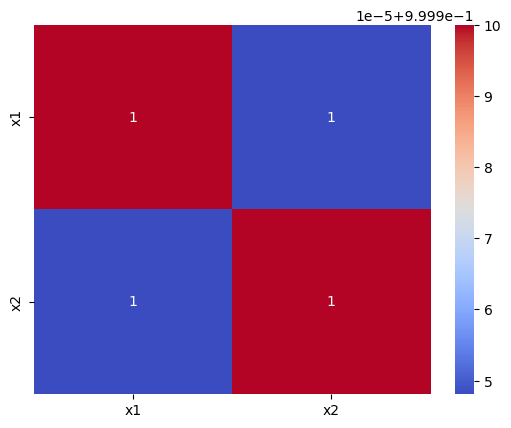

In [7]:
# Correlation matrix
import seaborn as sns
corr = X.corr()
print(corr)
sns.heatmap(corr, annot=True, cmap="coolwarm");

In [8]:
# Variance Inflation Factor (VIF)
    # VIF = 1 → no multicollinearity
    # VIF between 1 and 5 → usually acceptable
    # VIF above 5 → concerning
    # VIF above 10 → severe multicollinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor

# X should contain only predictor columns
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif_data

,Feature,VIF
0,x1,9615.541005
1,x2,9615.541005


## **3. Residual Patterns**


Residuals should look random.
- **Problem:** A pattern in residuals suggests the model is missing something.
- **Solution:** Transform variables (apply log, square root, etc) or Use a more flexible model


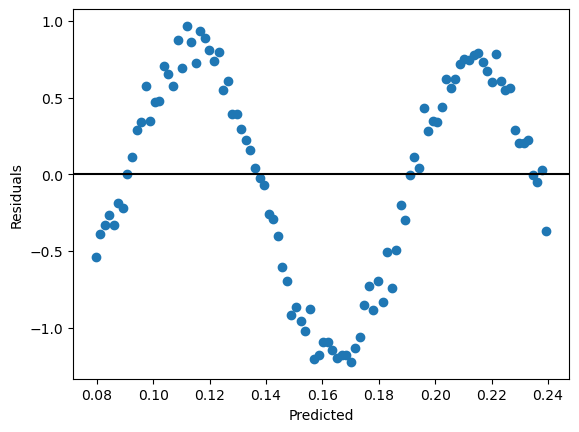

In [9]:
# Example

X = np.linspace(0, 10, 100).reshape(-1,1)
y = np.sin(X[:,0]) + np.random.normal(0,0.1,100)

model = LinearRegression().fit(X, y)
pred = model.predict(X)
residuals = y - pred

plt.scatter(pred, residuals)
plt.axhline(0, color='black')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show()


#### **Detection**

- Plot predicted vs residuals
- Plot residuals histogram (to verify normality)
- Q-Q plot (compares the quantiles of your data to the quantiles of the theoretical distribution (e.g., normal))

In [10]:
# Example Data
from sklearn.linear_model import LinearRegression
import scipy.stats as stats


np.random.seed(42)
X = np.linspace(0, 10, 100).reshape(-1, 1)
errors = np.random.normal(loc=0, scale=1, size=100)
y = 2 * X[:, 0] + 5 + errors

# Fit linear regression
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
residuals = y - y_pred

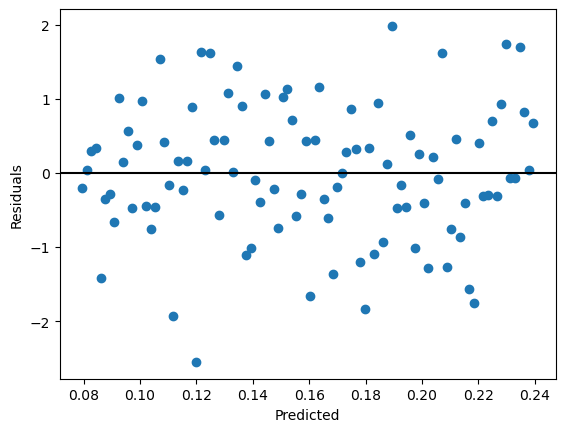

In [11]:
# Scatter predicted vs residuals
plt.scatter(pred, residuals)
plt.axhline(0, color='black')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show()

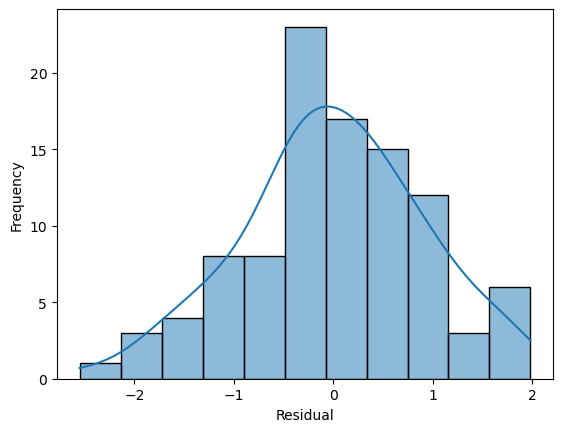

In [12]:
# Plot residuals histogram
sns.histplot(residuals, kde=True)
plt.xlabel("Residual")
plt.ylabel("Frequency");

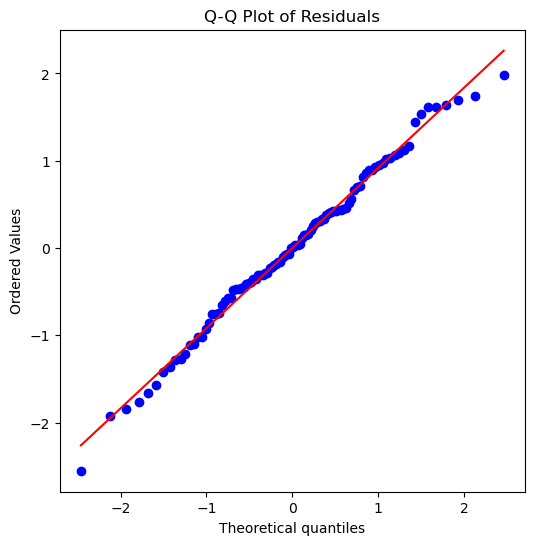

In [13]:
# Q-Q plot
# The Q-Q plot compares the quantiles of your data to the quantiles of the theoretical distribution (e.g., normal).
plt.figure(figsize=(6,6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals");

## **4. Non-Independent Errors**


- **Problem:** Residuals are not random; they depend on some variable (Time-series data often violates independence).
- **Solution:** Use lag features or time-series models.


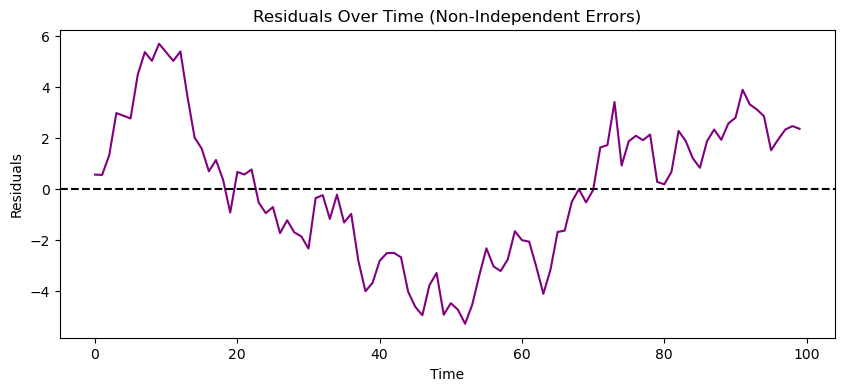

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Seed for reproducibility
np.random.seed(42)

# Time steps
time = np.arange(100)

# Linear trend
true_slope = 0.5
true_intercept = 5
trend = true_intercept + true_slope * time

# Autocorrelated errors: cumulative sum of random noise
errors = np.cumsum(np.random.normal(0, 1, size=100))

# Observed data
y = trend + errors

# Fit ordinary linear regression (ignoring autocorrelation)
model = LinearRegression()
model.fit(time.reshape(-1, 1), y)
y_pred = model.predict(time.reshape(-1, 1))

# Compute residuals
residuals = y - y_pred

# Plot residuals
plt.figure(figsize=(10,4))
plt.plot(time, residuals, color='purple')
plt.axhline(0, color='black', linestyle='--')
plt.title("Residuals Over Time (Non-Independent Errors)")
plt.xlabel("Time")
plt.ylabel("Residuals")
plt.show()

### **Detection**
- Plot residuals against time, order, or any variable not in the model.
- Plot residuals against lagged residuals (past value of a variable that you use as a predictor for the current value.)

Text(0, 0.5, 'Residuals')

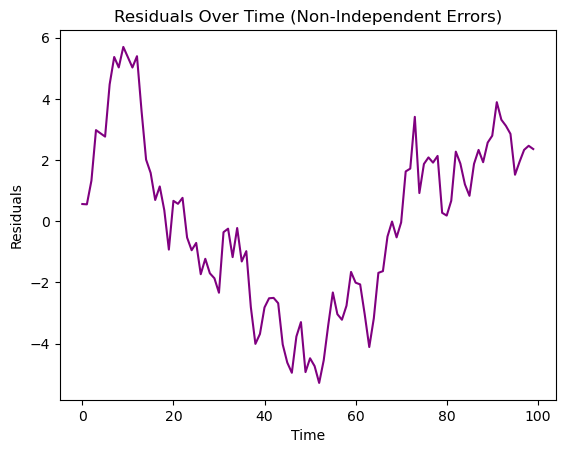

In [15]:
plt.plot(time, residuals, color='purple')
plt.title("Residuals Over Time (Non-Independent Errors)")
plt.xlabel("Time")
plt.ylabel("Residuals")

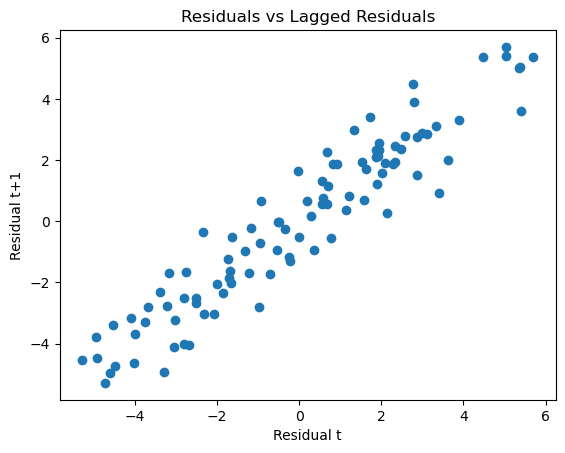

In [16]:
# Plot residuals against lagged residuals
# Strong linear relationship → residuals are dependent

plt.scatter(residuals[:-1], residuals[1:])
plt.xlabel("Residual t")
plt.ylabel("Residual t+1")
plt.title("Residuals vs Lagged Residuals")
plt.show()

## **5. Constant Variance (homoscedasticity)**
In Linear regression residuals (errors) should have the same variance across all levels of the predictors (i.e. scatter roughly the same amount at all predicted values)

- **Problem:** The variance of residuals changes across the range of predicted values.
- **Solution:** Transform the dependent variable (Use log, square root, etc) or Give less weight to observations with higher variance.

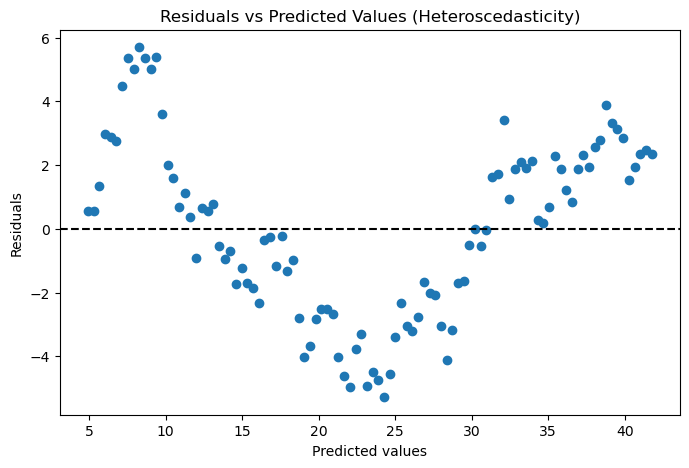

In [17]:
# Bad data Example (previous data)

plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals)
plt.axhline(0, color='black', linestyle='--')
plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values (Heteroscedasticity)")
plt.show()

## **Detection**

- Residuals vs predicted values plot
- Compute correlation between absolute residuals and predicted values.


In [18]:
# Good Data Example
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

np.random.seed(42)

# Predictor
X = np.linspace(1, 10, 100).reshape(-1, 1)

# Non-constant variance: error increases with X
errors = np.random.normal(0, 0.5 * X[:, 0], 100)

# Target variable
y = 2 * X[:, 0] + 5 + errors

# Fit linear regression
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
residuals = y - y_pred

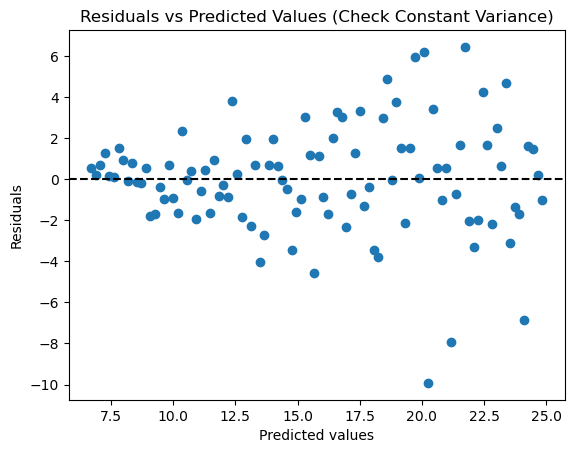

In [19]:
# Residuals vs predicted values plot
    # Good (homoscedasticity): residuals randomly scattered, roughly equal spread.
    # Bad (heteroscedasticity): funnel shape, increasing or decreasing spread as predicted values increase.
import matplotlib.pyplot as plt

plt.scatter(y_pred, residuals)
plt.axhline(0, color='black', linestyle='--')
plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values (Check Constant Variance)")
plt.show()

In [20]:
# Correlation of |Residuals| with predicted value
# Strong correlation → variance depends on X → heteroscedasticity.
corr = np.corrcoef(np.abs(residuals), y_pred)[0,1]
print("Correlation between |residuals| and predicted values:", corr)

Correlation between |residuals| and predicted values: 0.4112702949109159
